# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.0, "Pokemon's HP in Correlation to Attack and Defense")

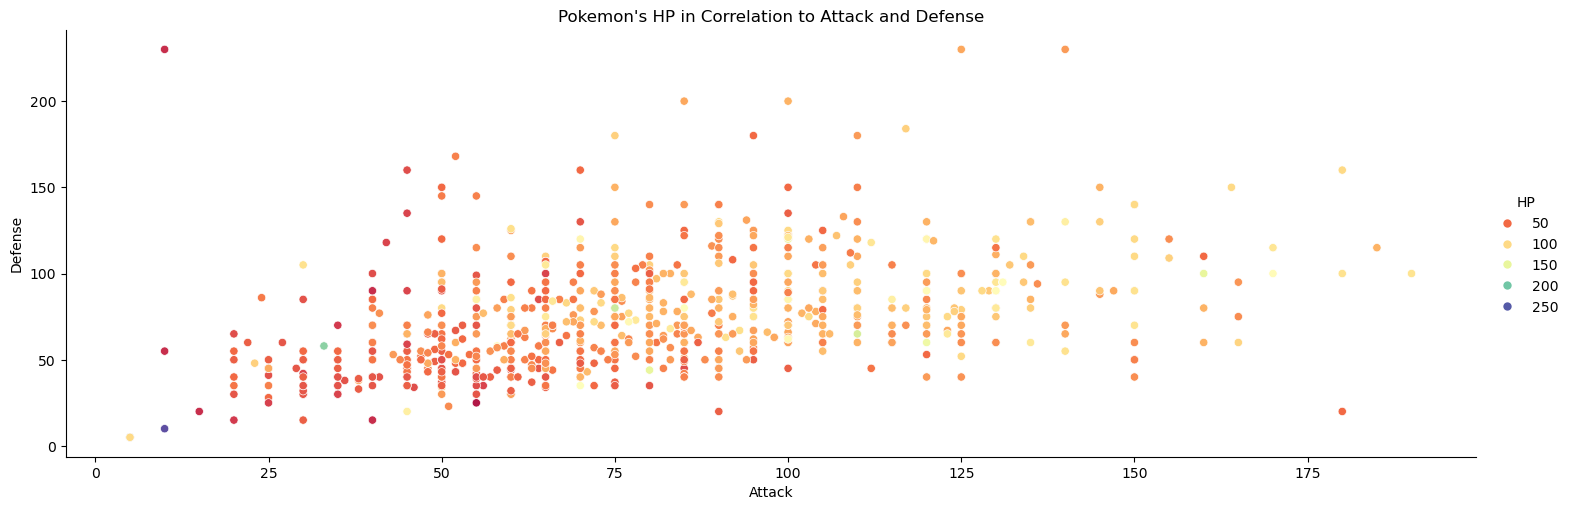

In [44]:
pokedex = pd.read_csv(fp)

sns.relplot(
    data=pokedex,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="Spectral",
    aspect=3.0
)

plt.title("Pokemon's HP in Correlation to Attack and Defense")


### From the plot, I observed....
Results: There is a positive correlation between Attack and Defense. The hit-points (HP) is higher for Pokemons with higher Attack and Defense values.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

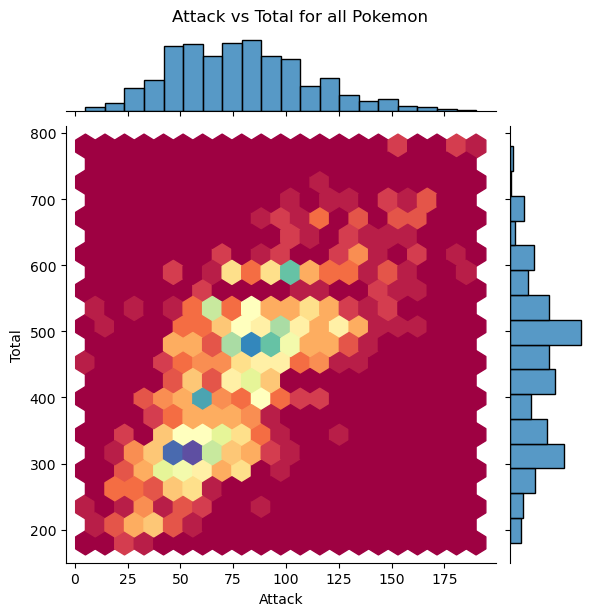

In [36]:
sns.jointplot(
    data=pokedex,
    x='Attack',
    y='Total',
    kind='hex',
    gridsize=20,
    cmap="Spectral"
)

plt.suptitle('Attack vs Total for all Pokemon', y=1.02)
plt.show()

From the plot, I observed a positive correlation between Attack and Total.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

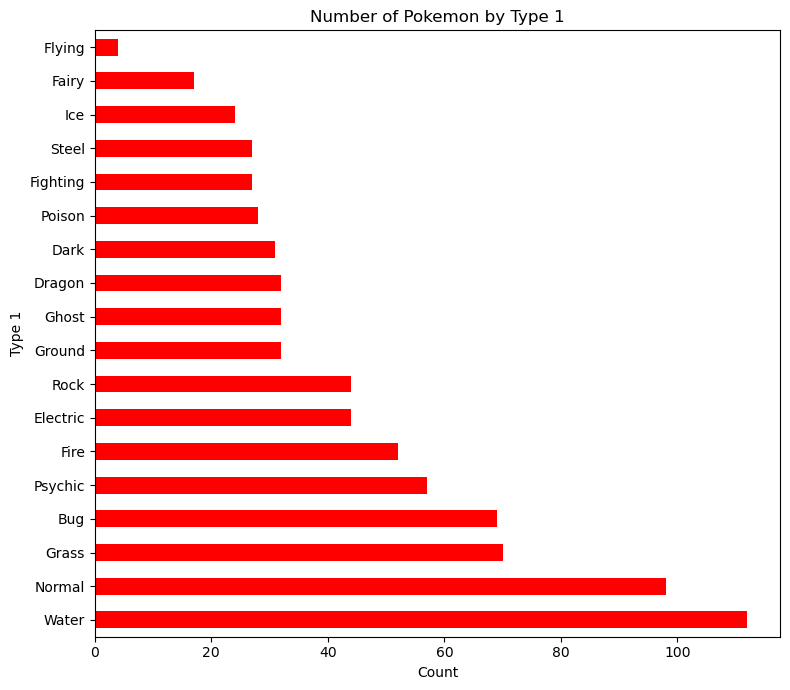

In [9]:
# Type 1
type1_counts = type2_counts = df['Type 2'].value_counts()['Type 1'].value_counts()

# Plot Type 1 counts, red

plt.figure(figsize=(8, 7))
type1_counts.plot(kind='barh', color='red')
plt.title('Number of Pokemon by Type 1')
plt.xlabel('Count')
plt.ylabel('Type 1')
plt.tight_layout()
plt.show()

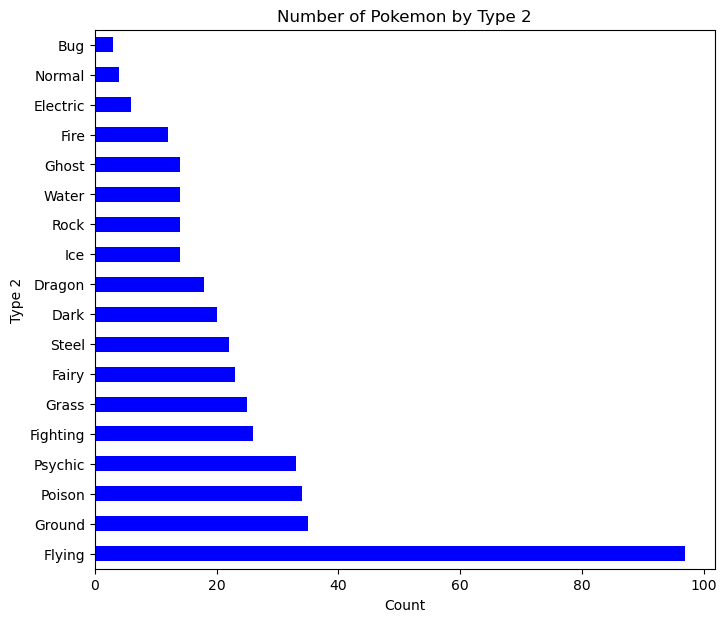

In [13]:
type2_counts = pokedex['Type 2'].value_counts()

plt.figure(figsize=(8, 7))
type2_counts.plot(kind='barh', color='blue')
plt.title('Number of Pokemon by Type 2')
plt.xlabel('Count')
plt.ylabel('Type 2')

plt.show()

**Type 1:** The most common primary type is water, followed by noraml and grass.
The rarest Type 1 is flying this is because flying usually shows up as another type, not a primary one.

**Type 2:** The most common secondary type is flying, which showes to us that many Pokémon are paired with flying.
The rarest secondary type is ice.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

## Q4: What is the distribution of Speed stats?

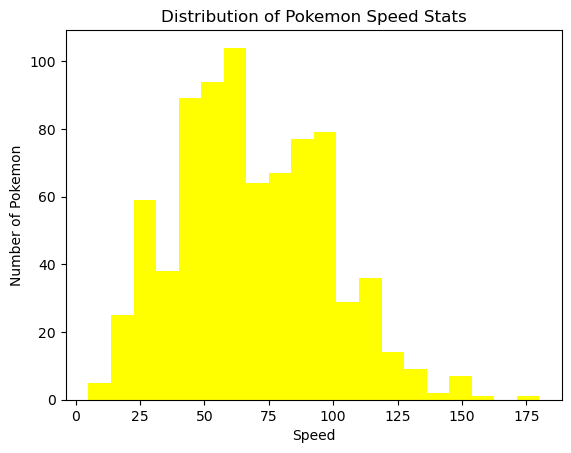

In [31]:

plt.figure()
plt.hist(pokedex['Speed'], bins=20, color='yellow')
plt.title('Distribution of Pokemon Speed Stats')
plt.xlabel('Speed')
plt.ylabel('Number of Pokemon')
plt.show()

My conclusion with this one is that there is a semi-bell curve showing that many of the pokemon the pokedex has an average speed shown around 30 to 100. Th most number of pokemon have a speed state of around 60.

## Q5: How many Pokemon are in each Generation?

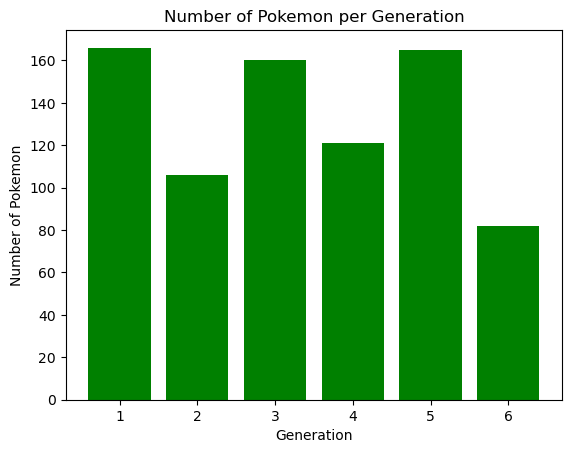

In [32]:
gen_counts = pokedex['Generation'].value_counts().sort_index()

plt.figure()
plt.bar(gen_counts.index, gen_counts.values, color='green')
plt.title('Number of Pokemon per Generation')
plt.xlabel('Generation')
plt.ylabel('Number of Pokemon')
plt.show()

This bar chart shows that there are around the same number of pokemon introduced in Gen 1 and Gen 5, withc Gen 3 close as well. There is usually a dip in number of pokemon in a following generation if the previous generation showed a large number of introductions, revealing a cyclical nature of release.

## Q6: What is the most common HP value?

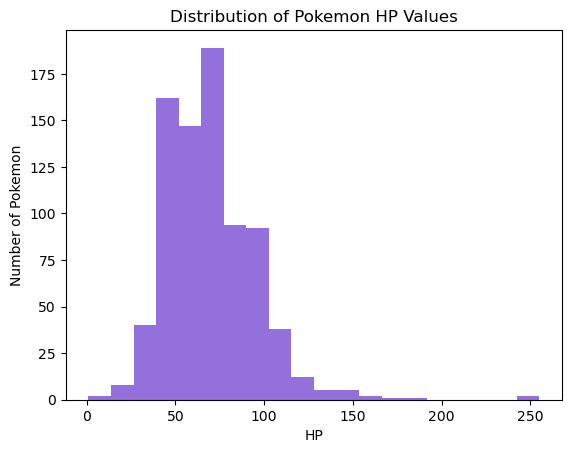

In [28]:
plt.figure()
plt.hist(pokedex['HP'], bins=20, color='mediumpurple')
plt.title('Distribution of Pokemon HP Values')
plt.xlabel('HP')
plt.ylabel('Number of Pokemon')
plt.show()

This histogram reveals that the majority of pokemon HP values are concentrated at the 50 to 75 mark, with a very small number of pokemon reaching a health point statistic of 250. it is also extremely uncommon to have a pokemon that has less than 25 HP.